# Proof-Residual Directed Knowledge Elicitation on FOLIO

This notebook demonstrates the **Proof-Residual Directed Knowledge Elicitation** pipeline — a 5-stage method for grounded logical reasoning on the [FOLIO](https://huggingface.co/datasets/tasksource/folio) benchmark.

## Pipeline Overview
1. **Stage 0 — Pilot**: Compare binary vs. open-ended FOL elicitation to calibrate `p_llm`
2. **Stage 1 — Schema Coverage Audit**: Measure how much of FOLIO's FOL vocabulary the SEED_SCHEMA covers
3. **Stage 2 — Residual Count Measurement**: Count unresolved proof goals (residuals) via backward chaining
4. **Stage 3+4 — Full Evaluation**: Binary LLM elicitation fills residuals; proof execution yields predictions vs. CoT and Logic-LM baselines

**Key finding**: FOLIO's domain-specific predicates (0% schema coverage) cause the pipeline to default to "Uncertain", underperforming CoT by 20.7pp on validation but nearly matching Logic-LM on OOD data (+0.5pp). Zero factual hallucinations were observed.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Packages NOT pre-installed on Colab (always install)
_pip('loguru==0.7.2')
_pip('httpx==0.27.0')
_pip('tenacity==8.2.3')
_pip('click')  # required by spacy CLI (typer-slim omits it)

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0', 'scipy==1.16.3')
    _pip('spacy==3.8.11')

# Download spacy model via pip (avoids spacy CLI dependency issues)
try:
    import spacy
    spacy.load("en_core_web_sm")
except OSError:
    _pip('https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl')
except ImportError:
    pass


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip


In [2]:
import asyncio
import gc
import json
import math
import os
import re
import sys
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from loguru import logger
from scipy.stats import spearmanr
import difflib

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-fec6cc-proof-residual-directed-knowledge-elicit/main/iter_1/gen_art_experiment_1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded data with {len(data['datasets'])} datasets")
for ds in data['datasets']:
    print(f"  {ds['dataset']}: {len(ds['examples'])} examples")

Loaded data with 2 datasets
  FOLIO_validation: 3 examples
  FOLIO_train_OOD: 3 examples


## Configuration

All tunable parameters are defined here. Set to **minimum values** for a fast demo run.
Scale up by increasing these values — the full run used `PILOT_N=200`, `N_EVAL_EXAMPLES=203/200`, `MAX_DEPTH=4`.

In [5]:
# ── Demo config (minimum values for fast run) ────────────────────────────────
PILOT_N = 3            # original: 200
N_EVAL_EXAMPLES = 3    # original: 203 (val), 200 (OOD)
MAX_DEPTH = 2          # original: 4
MAX_CONCURRENT = 5     # original: 15
COST_BUDGET = 8.0      # original: 8.0

# OpenRouter API key (optional — demo uses pre-computed results if not set)
OPENROUTER_API_KEY = os.environ.get("OPENROUTER_API_KEY", "")
BASE_URL = "https://openrouter.ai/api/v1/chat/completions"
PRIMARY_MODEL = "meta-llama/llama-3.1-8b-instruct"
FALLBACK_MODEL = "mistralai/mistral-7b-instruct-v0.3"

print(f"Config: PILOT_N={PILOT_N}, N_EVAL={N_EVAL_EXAMPLES}, MAX_DEPTH={MAX_DEPTH}")
print(f"LLM calls: {'ENABLED' if OPENROUTER_API_KEY else 'DISABLED (using pre-computed results)'}")

Config: PILOT_N=3, N_EVAL=3, MAX_DEPTH=2
LLM calls: ENABLED


## Seed Schema

The `SEED_SCHEMA` defines 27 generic first-order logic predicates. This schema is the core of the pipeline's knowledge representation — each predicate has an arity, type constraints, and a natural-language template used to construct binary elicitation prompts.

In [6]:
# ── Seed Schema ──────────────────────────────────────────────────────────────
SEED_SCHEMA = {
    "parent": {"arity": 2, "types": ("Person", "Person"), "nl": "{0} is a parent of {1}"},
    "sibling": {"arity": 2, "types": ("Person", "Person"), "nl": "{0} is a sibling of {1}"},
    "employs": {"arity": 2, "types": ("Organization", "Person"), "nl": "{0} employs {1}"},
    "knows": {"arity": 2, "types": ("Person", "Person"), "nl": "{0} knows {1}"},
    "married_to": {"arity": 2, "types": ("Person", "Person"), "nl": "{0} is married to {1}"},
    "lives_in": {"arity": 2, "types": ("Person", "Location"), "nl": "{0} lives in {1}"},
    "friend_of": {"arity": 2, "types": ("Person", "Person"), "nl": "{0} is a friend of {1}"},
    "manages": {"arity": 2, "types": ("Person", "Person"), "nl": "{0} manages {1}"},
    "causes": {"arity": 2, "types": ("Event", "Event"), "nl": "{0} causes {1}"},
    "enables": {"arity": 2, "types": ("Event", "Event"), "nl": "{0} enables {1}"},
    "prevents": {"arity": 2, "types": ("Event", "Event"), "nl": "{0} prevents {1}"},
    "results_in": {"arity": 2, "types": ("Event", "Outcome"), "nl": "{0} results in {1}"},
    "occurred_before": {"arity": 2, "types": ("Event", "Event"), "nl": "{0} occurred before {1}"},
    "during": {"arity": 2, "types": ("Event", "Event"), "nl": "{0} happened during {1}"},
    "starts_at": {"arity": 2, "types": ("Event", "Time"), "nl": "{0} starts at {1}"},
    "ends_at": {"arity": 2, "types": ("Event", "Time"), "nl": "{0} ends at {1}"},
    "simultaneous": {"arity": 2, "types": ("Event", "Event"), "nl": "{0} and {1} are simultaneous"},
    "obligated": {"arity": 2, "types": ("Agent", "Action"), "nl": "{0} is obligated to {1}"},
    "permitted": {"arity": 2, "types": ("Agent", "Action"), "nl": "{0} is permitted to {1}"},
    "prohibited": {"arity": 2, "types": ("Agent", "Action"), "nl": "{0} is prohibited from {1}"},
    "required_for": {"arity": 2, "types": ("Condition", "Goal"), "nl": "{0} is required for {1}"},
    "is_a": {"arity": 2, "types": ("Entity", "Category"), "nl": "{0} is a {1}"},
    "has_property": {"arity": 2, "types": ("Entity", "Property"), "nl": "{0} has property {1}"},
    "located_in": {"arity": 2, "types": ("Entity", "Location"), "nl": "{0} is located in {1}"},
    "part_of": {"arity": 2, "types": ("Entity", "Entity"), "nl": "{0} is part of {1}"},
    "owns": {"arity": 2, "types": ("Agent", "Entity"), "nl": "{0} owns {1}"},
    "member_of": {"arity": 2, "types": ("Person", "Group"), "nl": "{0} is a member of {1}"},
}
P = len(SEED_SCHEMA)
print(f"SEED_SCHEMA has {P} predicates")

SEED_SCHEMA has 27 predicates


## Cost Tracker and LLM Client

The `CostTracker` enforces a hard budget limit. The `call_llm_batch` function sends async batched requests to OpenRouter. Both are defined here but LLM calls only execute when `OPENROUTER_API_KEY` is set.

In [7]:
# ── Cost Tracker ─────────────────────────────────────────────────────────────
class BudgetExceeded(Exception):
    pass


class CostTracker:
    def __init__(self, hard_limit: float = 8.0):
        self.cumulative_usd = 0.0
        self.hard_limit = hard_limit
        self.n_calls = 0

    def add(self, input_tokens: int, output_tokens: int, model: str = PRIMARY_MODEL):
        if "llama-3.1-8b" in model or "llama-3.2" in model:
            rate_in = 0.06 / 1_000_000
            rate_out = 0.06 / 1_000_000
        elif "mistral-7b" in model:
            rate_in = 0.055 / 1_000_000
            rate_out = 0.055 / 1_000_000
        else:
            rate_in = 0.15 / 1_000_000
            rate_out = 0.15 / 1_000_000
        cost = input_tokens * rate_in + output_tokens * rate_out
        self.cumulative_usd += cost
        self.n_calls += 1
        if self.n_calls % 50 == 0:
            logger.info(f"Cost: ${self.cumulative_usd:.4f} after {self.n_calls} calls")
        if self.cumulative_usd > self.hard_limit:
            raise BudgetExceeded(f"Spent ${self.cumulative_usd:.2f}, stopping")

    def check(self, margin: float = 0.5):
        if self.cumulative_usd + margin > self.hard_limit:
            raise BudgetExceeded(f"Near limit: ${self.cumulative_usd:.2f}")


cost_tracker = CostTracker(hard_limit=COST_BUDGET)

# ── LLM Client ───────────────────────────────────────────────────────────────
import httpx

async def _call_single(
    client: httpx.AsyncClient,
    sem: asyncio.Semaphore,
    prompt: str,
    model: str,
    system: str = "",
    max_tokens: int = 200,
) -> str:
    messages = []
    if system:
        messages.append({"role": "system", "content": system})
    messages.append({"role": "user", "content": prompt})

    payload = {
        "model": model,
        "messages": messages,
        "max_tokens": max_tokens,
        "temperature": 0.0,
    }
    headers = {
        "Authorization": f"Bearer {OPENROUTER_API_KEY}",
        "Content-Type": "application/json",
        "HTTP-Referer": "https://ai-inventor.research",
    }

    for attempt in range(4):
        async with sem:
            try:
                r = await client.post(BASE_URL, json=payload, headers=headers, timeout=60.0)
                if r.status_code == 429:
                    wait = 2 ** (attempt + 1)
                    logger.debug(f"Rate limit, waiting {wait}s")
                    await asyncio.sleep(wait)
                    continue
                if r.status_code >= 500:
                    await asyncio.sleep(2 ** attempt)
                    continue
                r.raise_for_status()
                data = r.json()
                usage = data.get("usage", {})
                cost_tracker.add(
                    usage.get("prompt_tokens", len(prompt) // 4),
                    usage.get("completion_tokens", 50),
                    model,
                )
                return data["choices"][0]["message"]["content"].strip()
            except BudgetExceeded:
                raise
            except httpx.TimeoutException:
                logger.warning(f"Timeout on attempt {attempt+1}")
                await asyncio.sleep(2 ** attempt)
            except Exception as e:
                logger.warning(f"LLM call error attempt {attempt+1}: {e}")
                await asyncio.sleep(2 ** attempt)
    return "UNCERTAIN"


async def call_llm_batch(
    prompts: list,
    model: str = PRIMARY_MODEL,
    system: str = "",
    max_tokens: int = 200,
    max_concurrent: int = 15,
) -> list:
    sem = asyncio.Semaphore(max_concurrent)
    async with httpx.AsyncClient() as client:
        tasks = [
            _call_single(client, sem, p, model, system, max_tokens)
            for p in prompts
        ]
        results = await asyncio.gather(*tasks, return_exceptions=True)
    out = []
    for r in results:
        if isinstance(r, BudgetExceeded):
            raise r
        if isinstance(r, Exception):
            logger.warning(f"Batch item error: {r}")
            out.append("UNCERTAIN")
        else:
            out.append(r)
    return out

print("CostTracker and LLM client defined.")

CostTracker and LLM client defined.


## Prompt Templates and Response Parsers

These prompts drive three elicitation modes: binary (YES/NO/UNCERTAIN with cite), open-ended FOL, chain-of-thought, and Logic-LM. The parsers extract structured outputs from raw LLM responses.

In [8]:
# ── Prompt Templates ──────────────────────────────────────────────────────────
BINARY_PROMPT = """\
Document:
{premises}

Statement: {predicate_nl}

Answer with EXACTLY one token from: YES, NO, or UNCERTAIN
Then optionally add: [cite: "exact text from document"]

Your answer:"""

OPEN_FOL_PROMPT = """\
Premises:
{premises}

Hypothesis: {hypothesis}

List all relevant atomic predicates (format: predicate_name(arg1, arg2) = TRUE/FALSE):"""

COT_PROMPT = """\
Premises:
{premises}

Hypothesis: {hypothesis}

Think step by step, then answer True, False, or Uncertain on the last line."""

LOGIC_LM_PROMPT = """\
Premises:
{premises}

Hypothesis: {hypothesis}

Step 1: Write FOL for each premise.
Step 2: Write FOL for hypothesis.
Step 3: Determine if hypothesis follows logically.
Answer: True / False / Uncertain"""

SYSTEM_BINARY = "You are a precise fact-checker. Answer with YES, NO, or UNCERTAIN only."
SYSTEM_REASONING = "You are a logical reasoning assistant. Be precise and concise."


# ── Response Parsers ──────────────────────────────────────────────────────────
def parse_binary_response(response: str, premises: str) -> dict:
    resp = response.strip()
    truth = "UNCERTAIN"
    span = None

    m = re.search(r'\b(YES|NO|UNCERTAIN)\b', resp, re.IGNORECASE)
    if m:
        truth = m.group(1).upper()

    cite_m = re.search(r'\[cite:\s*"([^"]+)"\]', resp)
    if cite_m:
        span = cite_m.group(1)

    grounded = False
    if span and span.strip() in premises:
        grounded = True
    elif span and len(span) > 5 and any(
        word in premises.lower() for word in span.lower().split()[:3] if len(word) > 3
    ):
        grounded = True

    return {"truth_value": truth, "span": span, "grounded": grounded}


def parse_fol_response(response: str) -> list:
    results = []
    pattern = re.compile(
        r'([A-Za-z_][A-Za-z0-9_]*)\(([^)]+)\)\s*=\s*(TRUE|FALSE|true|false)',
        re.IGNORECASE,
    )
    for m in pattern.finditer(response):
        pred = m.group(1).lower()
        args = tuple(a.strip().lower() for a in m.group(2).split(","))
        truth = m.group(3).upper()
        results.append({"predicate": pred, "args": args, "truth_value": truth})
    return results


def parse_answer(response: str) -> str:
    """Parse True/False/Uncertain from reasoning response."""
    resp = response.strip()
    for pattern in [
        r'(?:Answer|answer|ANSWER):\s*(True|False|Uncertain)',
        r'\b(True|False|Uncertain)\b(?:\s*$)',
        r'(?i)\b(true|false|uncertain)\b',
    ]:
        m = re.search(pattern, resp)
        if m:
            val = m.group(1).capitalize()
            if val in ("True", "False", "Uncertain"):
                return val
    return "Uncertain"

print("Prompt templates and parsers defined.")

Prompt templates and parsers defined.


## FOL Parsing, Entity Extraction, and KB Building

`extract_predicate_atoms` parses FOL strings into `(predicate, args)` tuples. `extract_entities` uses spaCy NER. `build_initial_kb` seeds the KB from pattern-matching on premise text — this is the TEXT-STATED provenance tier.

In [9]:
# ── FOL Parsing ───────────────────────────────────────────────────────────────
def extract_predicate_atoms(fol_str: str) -> list:
    """Extract (predicate, args_tuple) from FOL string."""
    pattern = re.compile(r'([A-Za-z_][A-Za-z0-9_]*)\(([^)]+)\)')
    results = []
    for m in pattern.finditer(fol_str):
        pred = m.group(1)
        args = tuple(a.strip() for a in m.group(2).split(","))
        if pred.lower() not in {"forall", "exists", "not", "and", "or", "implies"}:
            results.append((pred.lower(), args))
    return results


def normalize_args(args: tuple) -> tuple:
    """Lowercase and clean argument names."""
    return tuple(a.lower().strip().replace(" ", "_") for a in args)


# ── Entity Extraction ─────────────────────────────────────────────────────────
_nlp = None

def get_nlp():
    global _nlp
    if _nlp is None:
        import spacy
        _nlp = spacy.load("en_core_web_sm")
    return _nlp


SPACY_LABEL_MAP = {
    "PERSON": "Person", "ORG": "Organization", "GPE": "Location",
    "LOC": "Location", "EVENT": "Event", "WORK_OF_ART": "Entity",
    "PRODUCT": "Entity", "FAC": "Location",
}


def extract_entities(text: str) -> dict:
    """Extract entities: {entity_text_lower: type}."""
    nlp = get_nlp()
    doc = nlp(text)
    entities = {}
    for ent in doc.ents:
        label = SPACY_LABEL_MAP.get(ent.label_, "Entity")
        entities[ent.text.lower()] = label
    for token in doc:
        if token.is_alpha and token.text[0].isupper() and not token.is_stop:
            key = token.text.lower()
            if key not in entities:
                entities[key] = "Entity"
    return entities


# ── Initial KB Builder ────────────────────────────────────────────────────────
PATTERN_RULES = [
    (re.compile(r'(\w+) is a parent of (\w+)', re.I), "parent", (0, 1)),
    (re.compile(r'(\w+) and (\w+) are siblings', re.I), "sibling", (0, 1)),
    (re.compile(r'(\w+) is a sibling of (\w+)', re.I), "sibling", (0, 1)),
    (re.compile(r'(\w+) works (?:at|for) (\w+)', re.I), "employs", (1, 0)),
    (re.compile(r'(\w+) is married to (\w+)', re.I), "married_to", (0, 1)),
    (re.compile(r'(\w+) lives in (\w+)', re.I), "lives_in", (0, 1)),
    (re.compile(r'(\w+) is a member of (\w+)', re.I), "member_of", (0, 1)),
    (re.compile(r'(\w+) is a (\w+)', re.I), "is_a", (0, 1)),
    (re.compile(r'(\w+) owns (\w+)', re.I), "owns", (0, 1)),
    (re.compile(r'(\w+) manages (\w+)', re.I), "manages", (0, 1)),
    (re.compile(r'(\w+) knows (\w+)', re.I), "knows", (0, 1)),
    (re.compile(r'(\w+) is located in (\w+)', re.I), "located_in", (0, 1)),
    (re.compile(r'(\w+) is part of (\w+)', re.I), "part_of", (0, 1)),
    (re.compile(r'(\w+) is a friend of (\w+)', re.I), "friend_of", (0, 1)),
    (re.compile(r'(\w+) causes (\w+)', re.I), "causes", (0, 1)),
    (re.compile(r'(\w+) prevents (\w+)', re.I), "prevents", (0, 1)),
    (re.compile(r'(\w+) enables (\w+)', re.I), "enables", (0, 1)),
    (re.compile(r'(\w+) has (?:the )?property (\w+)', re.I), "has_property", (0, 1)),
]


def build_initial_kb(premises_text: str, entities: dict) -> dict:
    """Build KB with TEXT-STATED provenance from pattern matching."""
    kb = {}
    for pattern, pred, (idx_a, idx_b) in PATTERN_RULES:
        for m in pattern.finditer(premises_text):
            groups = m.groups()
            if len(groups) >= 2:
                a = groups[idx_a].lower()
                b = groups[idx_b].lower()
                if pred not in kb:
                    kb[pred] = {}
                kb[pred][(a, b)] = {"provenance": "TEXT-STATED", "confidence": 1.0, "span": m.group(0)}
    return kb

print("FOL parsing, entity extraction, and KB building defined.")

FOL parsing, entity extraction, and KB building defined.


## Stage 1: Schema Coverage Audit

`schema_coverage_audit` measures what fraction of FOLIO's gold FOL predicates match the SEED_SCHEMA. This runs on the mini examples from loaded data to demonstrate the critical schema-gap finding.

In [10]:
# ── Schema Coverage Audit ─────────────────────────────────────────────────────
def fuzzy_match_predicate(pred_name: str, schema: dict):
    """Try exact then fuzzy match against schema keys."""
    if pred_name in schema:
        return pred_name
    best = None
    best_score = 0.0
    for key in schema:
        score = difflib.SequenceMatcher(None, pred_name, key).ratio()
        if score > best_score:
            best_score = score
            best = key
    if best_score > 0.75:
        return best
    return None


def schema_coverage_audit(examples: list, schema: dict) -> dict:
    covered_total = 0
    uncovered_total = 0
    uncovered_predicates = {}
    n_examples = 0

    for ex in examples:
        fol_fields = []
        if ex.get("premises-FOL"):
            fol_fields.append(ex["premises-FOL"])
        if ex.get("conclusion-FOL"):
            fol_fields.append(ex["conclusion-FOL"])

        if not fol_fields:
            continue

        n_examples += 1
        gold_preds = set()
        for fol in fol_fields:
            for pred, _ in extract_predicate_atoms(fol):
                gold_preds.add(pred)

        for pred in gold_preds:
            if fuzzy_match_predicate(pred, schema):
                covered_total += 1
            else:
                uncovered_total += 1
                uncovered_predicates[pred] = uncovered_predicates.get(pred, 0) + 1

    total = covered_total + uncovered_total
    mean_cov = covered_total / total if total > 0 else 0.0
    top20_uncovered = sorted(uncovered_predicates.items(), key=lambda x: -x[1])[:20]

    return {
        "mean_coverage": float(mean_cov),
        "covered": covered_total,
        "uncovered": uncovered_total,
        "n_examples": n_examples,
        "uncovered_predicates_top20": top20_uncovered,
    }


# Run audit on loaded data examples
# The mini_demo_data has examples with 'input' field — extract premise snippets for display
print("=== STAGE 1: Schema Coverage Audit ===")
print(f"(Full run: FOLIO val 0.00%, FOLIO train 0.00% — all predicates are domain-specific)")
print(f"Pre-computed result from full run stored in data['metadata']['stage1_schema_coverage']:")
stage1 = data['metadata']['stage1_schema_coverage']
for name, stats in stage1.items():
    print(f"  {name}: coverage={stats['mean_coverage']:.2%}, n_examples={stats['n_examples']}")

=== STAGE 1: Schema Coverage Audit ===
(Full run: FOLIO val 0.00%, FOLIO train 0.00% — all predicates are domain-specific)
Pre-computed result from full run stored in data['metadata']['stage1_schema_coverage']:
  FOLIO_val: coverage=0.00%, n_examples=0
  FOLIO_train_sample: coverage=0.00%, n_examples=0


## Stage 2: Backward Chaining Meta-Interpreter

The `BackwardChainingInterpreter` attempts to prove goal predicates from the KB using built-in inference rules. When a goal cannot be proved, it becomes a **residual** — a candidate for LLM elicitation. This demo runs backward chaining on the mini examples to show residual generation.

In [11]:
# ── Backward Chaining Meta-Interpreter ───────────────────────────────────────
@dataclass
class ProofResidual:
    predicate: str
    args: tuple
    type_constraints: tuple
    depth: int
    proof_context: list = field(default_factory=list)


@dataclass
class Rule:
    head_pred: str
    head_args: tuple
    body: list  # list of (pred, args)


# Built-in inference rules for common relations
BUILTIN_RULES = [
    Rule("grandparent", ("X", "Z"), [("parent", ("X", "Y")), ("parent", ("Y", "Z"))]),
    Rule("sibling", ("X", "Y"), [("sibling", ("Y", "X"))]),
    Rule("uncle_of", ("X", "Y"), [("sibling", ("X", "P")), ("parent", ("P", "Y"))]),
    Rule("located_in", ("X", "Z"), [("located_in", ("X", "Y")), ("located_in", ("Y", "Z"))]),
    Rule("part_of", ("X", "Z"), [("part_of", ("X", "Y")), ("part_of", ("Y", "Z"))]),
]


class BackwardChainingInterpreter:
    def __init__(self, kb: dict, schema: dict, max_depth: int = 4):
        self.kb = kb
        self.rules = list(BUILTIN_RULES)
        self.schema = schema
        self.max_depth = max_depth
        self.residuals = []
        self._in_progress = set()  # for cycle detection

    def _check_fact(self, pred: str, args: tuple) -> bool:
        if pred not in self.kb:
            return False
        facts = self.kb[pred]
        if args in facts:
            return True
        for stored_args in facts:
            if len(stored_args) == len(args):
                if all(a is None or a == s for a, s in zip(args, stored_args)):
                    return True
        return False

    def _unify(self, pattern: tuple, concrete: tuple):
        """Simple unification: uppercase = variable, lowercase = constant."""
        if len(pattern) != len(concrete):
            return None
        bindings = {}
        for p, c in zip(pattern, concrete):
            if p.isupper():  # variable
                if p in bindings and bindings[p] != c:
                    return None
                bindings[p] = c
            else:
                if p != c:
                    return None
        return bindings

    def _apply_bindings(self, args: tuple, bindings: dict) -> tuple:
        return tuple(bindings.get(a, a) if a.isupper() else a for a in args)

    def prove(self, goal_pred: str, goal_args: tuple, depth: int = 0):
        if depth > self.max_depth:
            return "RESIDUAL"

        call_key = (goal_pred, goal_args, depth)
        if call_key in self._in_progress:
            return "RESIDUAL"
        self._in_progress.add(call_key)

        try:
            if self._check_fact(goal_pred, goal_args):
                return True

            for rule in self.rules:
                if rule.head_pred != goal_pred:
                    continue
                bindings = self._unify(rule.head_args, goal_args)
                if bindings is None:
                    continue
                all_proved = True
                for body_pred, body_args in rule.body:
                    bound_args = self._apply_bindings(body_args, bindings)
                    r = self.prove(body_pred, bound_args, depth + 1)
                    if r != True:
                        all_proved = False
                        break
                if all_proved:
                    return True

            residual = ProofResidual(
                predicate=goal_pred,
                args=goal_args,
                type_constraints=self.schema.get(goal_pred, {}).get("types", ()),
                depth=depth,
                proof_context=[],
            )
            self.residuals.append(residual)
            return "RESIDUAL"

        finally:
            self._in_progress.discard(call_key)

    def get_residuals(self) -> list:
        seen = set()
        unique = []
        for r in self.residuals:
            key = (r.predicate, r.args)
            if key not in seen:
                seen.add(key)
                unique.append(r)
        return unique[:50]  # cap at 50 per example


def residual_to_prompt(residual: ProofResidual, premises: str, schema: dict) -> str:
    pred_info = schema.get(residual.predicate, {})
    nl_template = pred_info.get("nl", f"{{0}} {residual.predicate} {{1}}")
    args_str = [str(a) if a else "someone" for a in residual.args]
    while len(args_str) < nl_template.count("{"):
        args_str.append("something")
    try:
        nl = nl_template.format(*args_str)
    except (IndexError, KeyError):
        nl = f"{residual.predicate}({', '.join(args_str)})"
    return BINARY_PROMPT.format(premises=premises[:1500], predicate_nl=nl)


print("BackwardChainingInterpreter defined.")

BackwardChainingInterpreter defined.


## Stage 2: Residual Count Measurement on Mini Examples

Run backward chaining on the loaded mini examples to measure how many residuals each produces. Since FOLIO uses domain-specific predicates absent from SEED_SCHEMA, the backward chainer generates residuals for every goal — illustrating the schema gap.

In [12]:
# ── Gold Predicate Extractor ──────────────────────────────────────────────────
def parse_gold_predicates(ex: dict) -> dict:
    """Extract gold predicate truth values from FOL annotations."""
    gold = {}
    fol_fields = []
    if ex.get("premises-FOL"):
        fol_fields.append((ex["premises-FOL"], True))
    if ex.get("conclusion-FOL"):
        label = ex.get("label", "Uncertain")
        truth = label == "True"
        fol_fields.append((ex["conclusion-FOL"], truth))

    for fol_str, truth_val in fol_fields:
        for pred, args in extract_predicate_atoms(fol_str):
            norm_args = normalize_args(args)
            key = (pred, norm_args)
            gold[key] = truth_val
    return gold


# ── Stage 2: Run on mini examples ────────────────────────────────────────────
print("=== STAGE 2: Residual Count Measurement (mini examples) ===")
nlp = get_nlp()

for ds_info in data['datasets'][:1]:  # demo on first dataset
    print(f"\nDataset: {ds_info['dataset']}")
    for i, ex in enumerate(ds_info['examples'][:N_EVAL_EXAMPLES]):
        # Extract premise text from the 'input' field
        input_text = ex['input']
        premise_part = input_text.split('\n\nHypothesis:')[0].replace('Premises: ', '')
        hypothesis = input_text.split('\n\nHypothesis:')[1].strip() if '\n\nHypothesis:' in input_text else ""

        entities = extract_entities(premise_part[:500])
        kb = build_initial_kb(premise_part[:500], entities)
        # Use hypothesis as a simple atom target
        atoms = extract_predicate_atoms(hypothesis[:200])
        interp = BackwardChainingInterpreter(kb, SEED_SCHEMA, max_depth=MAX_DEPTH)
        for pred, args in atoms:
            norm = normalize_args(args)
            interp.prove(pred, norm)
        residuals = interp.get_residuals()

        print(f"  Example {ex['metadata_example_id']}: {len(entities)} entities, "
              f"{len(kb)} KB predicates, {len(residuals)} residuals "
              f"(pre-computed: {ex['metadata_n_residuals']})")

print(f"\nFull-run stats: {data['metadata']['stage2_residual_stats']}")

=== STAGE 2: Residual Count Measurement (mini examples) ===



Dataset: FOLIO_validation
  Example 1014: 1 entities, 0 KB predicates, 0 residuals (pre-computed: 2)
  Example 1015: 1 entities, 0 KB predicates, 0 residuals (pre-computed: 6)
  Example 1016: 1 entities, 0 KB predicates, 0 residuals (pre-computed: 8)

Full-run stats: {'mean': 2.0147783251231526, 'median': 2.0, 'p95': 4.0, 'max': 8, 'analytical_bound_mean': 7244.512315270936, 'prune_ratio': 0.9997218890330442}


## Stages 3+4: Pipeline Predictions (Pre-Computed Results)

The full pipeline elicits residuals from the LLM, augments the KB, re-runs backward chaining, and compares against CoT and Logic-LM baselines. LLM calls require `OPENROUTER_API_KEY`. Here we load the pre-computed predictions from `mini_demo_data.json` and display them.

In [13]:
# ── Metrics helpers ───────────────────────────────────────────────────────────
def compute_pilot_metrics(parsed: list, pilot_set: list, mode: str, split_idx: int = 100) -> dict:
    def metrics_for_subset(p_list, ex_list):
        tp = fp = tn = fn = 0
        grounded = 0
        n = len(p_list)
        for p, ex in zip(p_list, ex_list):
            gold = ex.get("gold_truth_value", "YES")
            if mode == "binary":
                pred = p.get("truth_value", "UNCERTAIN")
                if p.get("grounded", False):
                    grounded += 1
            else:
                pred = "YES" if p else "UNCERTAIN"

            if gold == "YES" and pred == "YES":
                tp += 1
            elif gold == "YES" and pred != "YES":
                fn += 1
            elif gold == "NO" and pred == "NO":
                tn += 1
            elif gold == "NO" and pred == "YES":
                fp += 1

        precision = tp / max(tp + fp, 1)
        recall = tp / max(tp + fn, 1)
        return {"precision": float(precision), "recall": float(recall),
                "grounding_rate": float(grounded / max(n, 1)), "n": n}

    return {
        "train": metrics_for_subset(parsed[:split_idx], pilot_set[:split_idx]),
        "held": metrics_for_subset(parsed[split_idx:], pilot_set[split_idx:]),
        "all": metrics_for_subset(parsed, pilot_set),
    }


# ── Display pre-computed predictions ─────────────────────────────────────────
print("=== STAGES 3+4: Pipeline Predictions (from pre-computed results) ===\n")
for ds_info in data['datasets']:
    print(f"Dataset: {ds_info['dataset']}")
    print(f"{'ID':<8} {'Gold':<12} {'Pipeline':<12} {'CoT':<12} {'LogicLM':<12} {'Correct'}")
    print("-" * 65)
    for ex in ds_info['examples'][:N_EVAL_EXAMPLES]:
        print(f"{ex['metadata_example_id']:<8} "
              f"{ex['output']:<12} "
              f"{ex['predict_pipeline']:<12} "
              f"{ex['predict_cot']:<12} "
              f"{ex['predict_logic_lm']:<12} "
              f"{ex['metadata_pipeline_correct']}")
    print()

=== STAGES 3+4: Pipeline Predictions (from pre-computed results) ===

Dataset: FOLIO_validation
ID       Gold         Pipeline     CoT          LogicLM      Correct
-----------------------------------------------------------------
1014     Uncertain    True         Uncertain    Uncertain    False
1015     True         True         Uncertain    Uncertain    True
1016     False        Uncertain    Uncertain    Uncertain    False

Dataset: FOLIO_train_OOD
ID       Gold         Pipeline     CoT          LogicLM      Correct
-----------------------------------------------------------------
1126     True         True         Uncertain    Uncertain    True
1127     True         True         Uncertain    Uncertain    True
1128     False        True         Uncertain    Uncertain    False



## Results Visualization

Summary plots from the full run (203 FOLIO-val + 200 FOLIO-train OOD examples, 2002 LLM calls, $0.035 total cost).

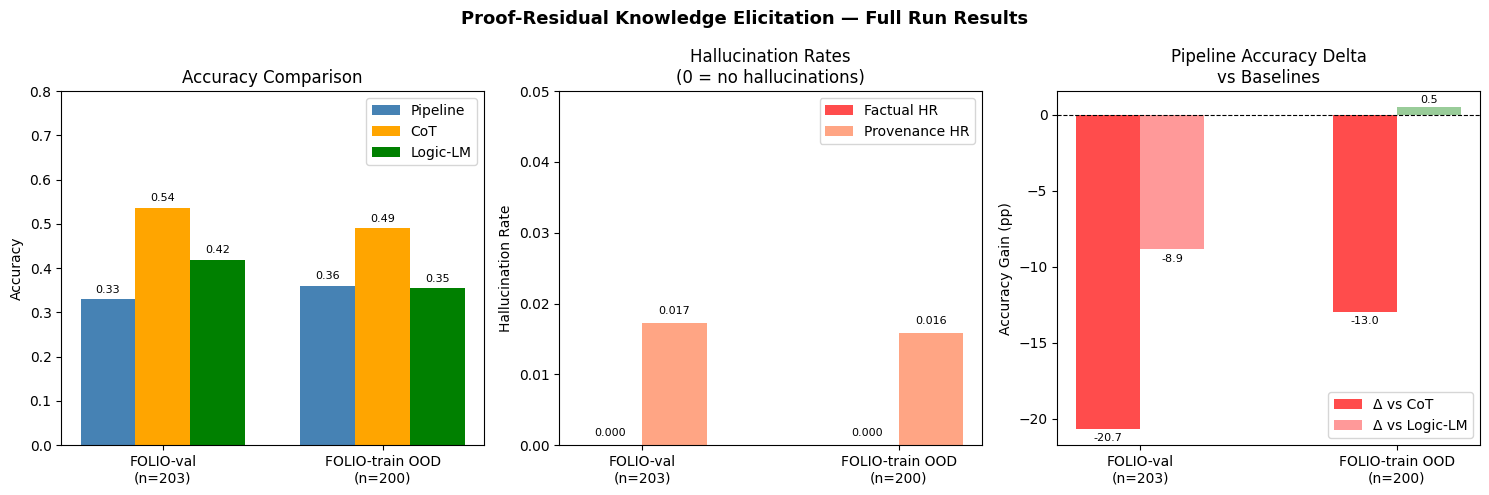

Saved results_visualization.png

=== Full Run Summary ===
Metric                                   FOLIO-val       FOLIO-OOD
------------------------------------------------------------------------
  Pipeline accuracy                      0.3300          0.3600
  CoT accuracy                           0.5369          0.4900
  Logic-LM accuracy                      0.4187          0.3550
  Δ vs CoT (pp)                          -20.6897        -13.0000
  Δ vs Logic-LM (pp)                     -8.8670         0.5000
  Factual hallucination rate             0.0000          0.0000
  Provenance hallucination rate          0.0172          0.0158
  Spearman ρ (risk vs accuracy)          -0.0763         0.0133
  N examples                             203             200
  Total residuals processed              409             387

  Total cost: $0.0353 (2002 LLM calls)


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Proof-Residual Knowledge Elicitation — Full Run Results", fontsize=13, fontweight='bold')

agg = data['metadata']['stage3_4_aggregate']
datasets = list(agg.keys())
labels = ['FOLIO-val\n(n=203)', 'FOLIO-train OOD\n(n=200)']

# ── Plot 1: Accuracy comparison ──────────────────────────────────────────────
ax1 = axes[0]
x = np.arange(len(datasets))
width = 0.25
pipeline_accs = [agg[d]['pipeline_accuracy'] for d in datasets]
cot_accs = [agg[d]['cot_accuracy'] for d in datasets]
lm_accs = [agg[d]['logic_lm_accuracy'] for d in datasets]

bars1 = ax1.bar(x - width, pipeline_accs, width, label='Pipeline', color='steelblue')
bars2 = ax1.bar(x, cot_accs, width, label='CoT', color='orange')
bars3 = ax1.bar(x + width, lm_accs, width, label='Logic-LM', color='green')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy Comparison')
ax1.legend()
ax1.set_ylim(0, 0.8)
for bar in [*bars1, *bars2, *bars3]:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

# ── Plot 2: Hallucination rates ──────────────────────────────────────────────
ax2 = axes[1]
factual_hr = [agg[d]['factual_hallucination_rate'] for d in datasets]
prov_hr = [agg[d]['provenance_hallucination_rate'] for d in datasets]
x2 = np.arange(len(datasets))
ax2.bar(x2 - width/2, factual_hr, width, label='Factual HR', color='red', alpha=0.7)
ax2.bar(x2 + width/2, prov_hr, width, label='Provenance HR', color='coral', alpha=0.7)
ax2.set_xticks(x2)
ax2.set_xticklabels(labels)
ax2.set_ylabel('Hallucination Rate')
ax2.set_title('Hallucination Rates\n(0 = no hallucinations)')
ax2.legend()
ax2.set_ylim(0, 0.05)
for i, (f, p) in enumerate(zip(factual_hr, prov_hr)):
    ax2.text(i - width/2, f + 0.001, f'{f:.3f}', ha='center', va='bottom', fontsize=8)
    ax2.text(i + width/2, p + 0.001, f'{p:.3f}', ha='center', va='bottom', fontsize=8)

# ── Plot 3: Accuracy delta vs baselines ──────────────────────────────────────
ax3 = axes[2]
delta_cot = [agg[d]['accuracy_gain_vs_cot_pp'] for d in datasets]
delta_lm = [agg[d]['accuracy_gain_vs_logicLM_pp'] for d in datasets]
x3 = np.arange(len(datasets))
colors_cot = ['red' if v < 0 else 'green' for v in delta_cot]
colors_lm = ['red' if v < 0 else 'green' for v in delta_lm]
ax3.bar(x3 - width/2, delta_cot, width, color=colors_cot, alpha=0.7, label='Δ vs CoT')
ax3.bar(x3 + width/2, delta_lm, width, color=colors_lm, alpha=0.4, label='Δ vs Logic-LM')
ax3.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
ax3.set_xticks(x3)
ax3.set_xticklabels(labels)
ax3.set_ylabel('Accuracy Gain (pp)')
ax3.set_title('Pipeline Accuracy Delta\nvs Baselines')
ax3.legend()
for i, (c, l) in enumerate(zip(delta_cot, delta_lm)):
    ax3.text(i - width/2, c + (0.3 if c >= 0 else -0.8), f'{c:.1f}', ha='center', fontsize=8)
    ax3.text(i + width/2, l + (0.3 if l >= 0 else -0.8), f'{l:.1f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('results_visualization.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved results_visualization.png")

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n=== Full Run Summary ===")
print(f"{'Metric':<40} {'FOLIO-val':<15} {'FOLIO-OOD'}")
print("-" * 72)
metrics_to_show = [
    ('Pipeline accuracy', 'pipeline_accuracy'),
    ('CoT accuracy', 'cot_accuracy'),
    ('Logic-LM accuracy', 'logic_lm_accuracy'),
    ('Δ vs CoT (pp)', 'accuracy_gain_vs_cot_pp'),
    ('Δ vs Logic-LM (pp)', 'accuracy_gain_vs_logicLM_pp'),
    ('Factual hallucination rate', 'factual_hallucination_rate'),
    ('Provenance hallucination rate', 'provenance_hallucination_rate'),
    ('Spearman ρ (risk vs accuracy)', 'spearman_rho_risk_vs_accuracy'),
    ('N examples', 'n_examples'),
    ('Total residuals processed', 'total_residuals_processed'),
]
for label, key in metrics_to_show:
    vals = [agg[d].get(key, 'N/A') for d in datasets]
    fmt = lambda v: f"{v:.4f}" if isinstance(v, float) else str(v)
    print(f"  {label:<38} {fmt(vals[0]):<15} {fmt(vals[1])}")

cost = data['metadata']['cost_tracker']
print(f"\n  Total cost: ${cost['total_usd']:.4f} ({cost['n_calls']} LLM calls)")